**Student Performance Analysis and Prediction**

In [44]:
import pandas as pd
import matplotlib.pylab as plt
import numpy as np
import statistics
import seaborn as sns

**Data Description**

Source:Kaggle


In [45]:
df=pd.read_csv("/content/student_performance_data_.csv")


**Data Preprocessing**

No missing values

Dropped student_id

Encoded categorical variables

In [46]:
print("\nFirst 5 rows:\n", df.head())



First 5 rows:
    student_id  gender  study_hours_per_day  attendance_percentage  \
0      100000    Male                 4.54                  69.98   
1      100001  Female                 5.26                  84.80   
2      100002    Male                 8.69                  73.76   
3      100003    Male                 4.06                  45.00   
4      100004    Male                 8.83                  51.13   

   assignment_score  midterm_score  final_exam_score  participation_score  \
0             36.47          70.70             53.10                17.96   
1             34.25          27.92             87.17                11.29   
2             72.29          70.92             99.61                76.10   
3             97.63          31.73             88.85                33.55   
4             65.19          78.28             54.23                88.99   

  internet_access extra_classes parent_education  sleep_hours  overall_score  \
0             Yes         

In [47]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1298 entries, 0 to 1297
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             1298 non-null   int64  
 1   gender                 1298 non-null   object 
 2   study_hours_per_day    1298 non-null   float64
 3   attendance_percentage  1298 non-null   float64
 4   assignment_score       1298 non-null   float64
 5   midterm_score          1298 non-null   float64
 6   final_exam_score       1298 non-null   float64
 7   participation_score    1298 non-null   float64
 8   internet_access        1298 non-null   object 
 9   extra_classes          1298 non-null   object 
 10  parent_education       1298 non-null   object 
 11  sleep_hours            1298 non-null   float64
 12  overall_score          1298 non-null   float64
 13  grade                  1298 non-null   object 
dtypes: float64(8), int64(1), object(5)
memory usage: 142.1+ 

In [48]:
df.describe()

,student_id,study_hours_per_day,attendance_percentage,assignment_score,midterm_score,final_exam_score,participation_score,sleep_hours,overall_score
count,1298.000000,1298.000000,1298.000000,1298.000000,1298.000000,1298.000000,1298.000000,1298.000000,1298.000000
mean,100648.500000,5.463112,69.859476,64.711680,62.288721,64.958143,55.464684,6.507111,63.782282
std,374.844634,2.606982,17.564180,19.753452,21.812320,20.330100,25.908985,1.448655,10.296159
min,100000.000000,1.040000,40.020000,30.010000,25.010000,30.140000,10.090000,4.000000,35.128000
25%,100324.250000,3.190000,54.467500,48.092500,42.902500,46.822500,33.367500,5.230000,56.125750
50%,100648.500000,5.410000,69.890000,64.550000,62.750000,65.630000,55.890000,6.550000,63.891500
75%,100972.750000,7.687500,85.392500,81.645000,81.030000,82.737500,78.167500,7.820000,71.329750
max,101297.000000,10.000000,100.000000,99.890000,99.860000,99.990000,99.920000,8.990000,92.383000


**Exploratory Data Analysis**



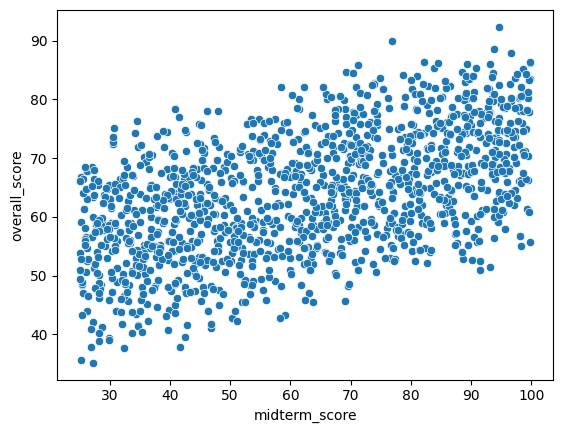

In [49]:
sns.scatterplot(x='midterm_score', y='overall_score', data=df)
plt.show()

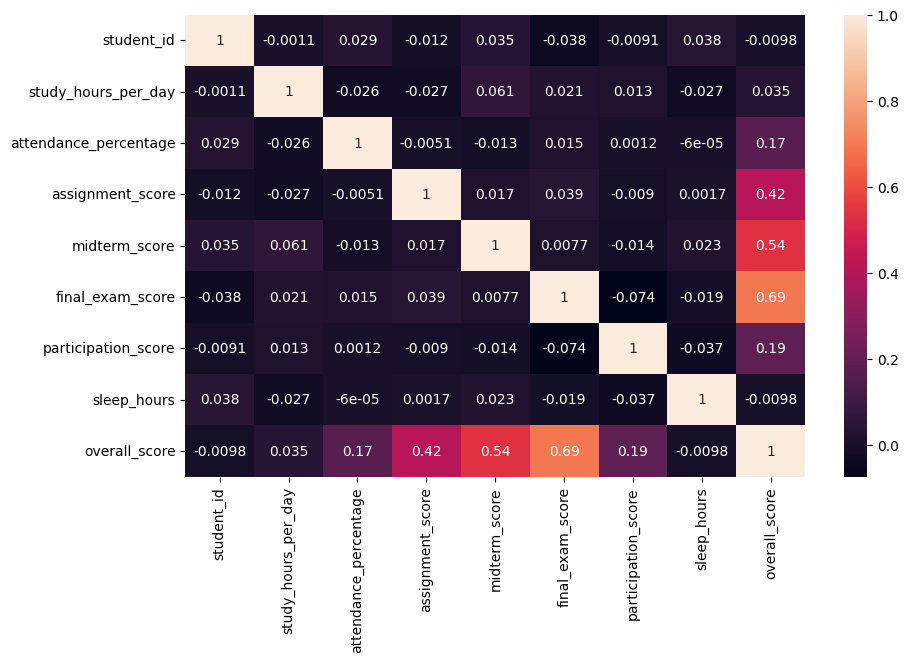

In [50]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True)
plt.show()

In [51]:
df['performance_score'] = (
    df['study_hours_per_day'] * 0.4 +
    df['attendance_percentage'] * 0.3 +
    df['overall_score'] * 0.3
)

<Axes: xlabel='result', ylabel='attendance_percentage'>

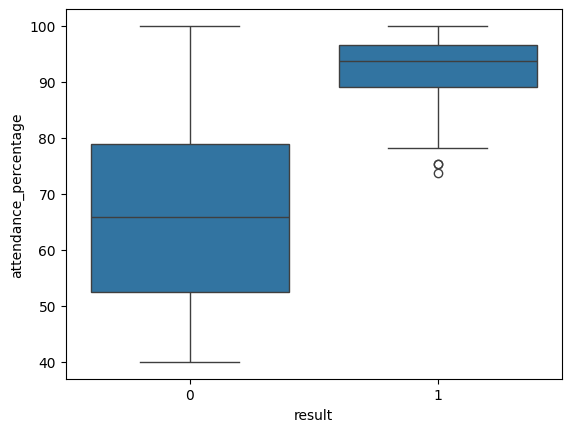

In [52]:

df['result'] = df['performance_score'].apply(lambda x: 1 if x >= 50 else 0)
sns.boxplot(x='result', y='attendance_percentage', data=df)

/tmp/ipykernel_4968/3267055417.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('study_group')['performance_score'].mean()


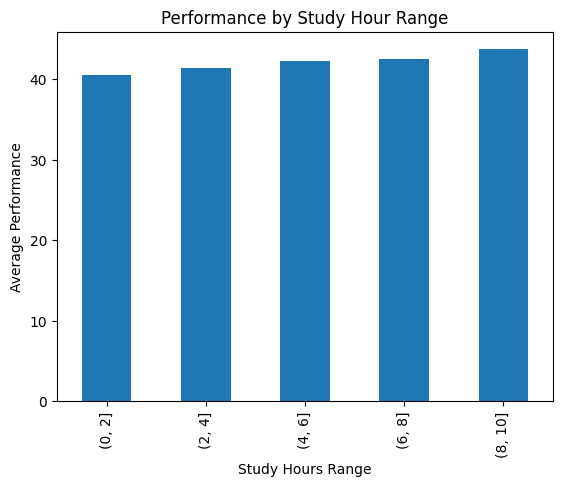

In [53]:

df['study_group'] = pd.cut(df['study_hours_per_day'], bins=[0,2,4,6,8,10])

grouped = df.groupby('study_group')['performance_score'].mean()

grouped.plot(kind='bar')
plt.xlabel("Study Hours Range")
plt.ylabel("Average Performance")
plt.title("Performance by Study Hour Range")
plt.show()

In [54]:
# Drop ID (not useful)
df_model = df.drop('student_id', axis=1)

# Convert categorical → numerical
df_model = pd.get_dummies(df_model, drop_first=True)

In [55]:
X = df_model.drop('overall_score', axis=1)
y = df_model['overall_score']

In [56]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [57]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

**Model Evaluation**


R² Score

RMSE

In [61]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

y_pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("RMSE:", rmse)

R2 Score: 1.0
RMSE: 1.1922273222804767e-14


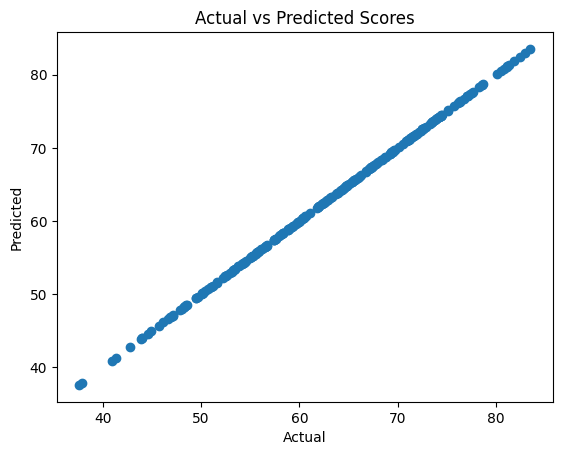

In [60]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted Scores")
plt.show()